<a href="https://colab.research.google.com/github/dbro-10/first_machine_learning_for_heart_disease/blob/main/kaggle_api_installer_%2B_first_ML_project_(heart_disease).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Set up and verify the Kaggle API in the Colab environment.

## Install Kaggle API Client

### Subtask:
Install the Kaggle API client library using pip.


**Reasoning**:
To install the Kaggle API client library, I will use the `!pip install kaggle` command in a code cell.



In [ ]:
!pip install kaggle
from google.colab import files

uploaded = files.upload()

import os

kaggle_dir = os.path.expanduser('~/.kaggle')
# Create the .kaggle directory if it doesn't exist
os.makedirs(kaggle_dir, exist_ok=True)

# Assuming the uploaded file is named 'kaggle api token (1).json' based on the kernel state
# Rename the uploaded file to 'kaggle.json' and move it to the .kaggle directory
uploaded_file_name = list(uploaded.keys())[0] # Get the actual uploaded file name
source_path = os.path.join('/content', uploaded_file_name)
destination_path = os.path.join(kaggle_dir, 'kaggle.json')

os.rename(source_path, destination_path)

# Set permissions to 600 (read/write only for the owner)
os.chmod(destination_path, 0o600)

print(f"Kaggle API key moved to {destination_path} and permissions set to 600.")

!kaggle datasets list

Saving kaggle api token.json to kaggle api token (1).json
Kaggle API key moved to /root/.kaggle/kaggle.json and permissions set to 600.
ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ayeshaimran123/social-media-and-mental-health-balance              Social Media and Mental Health Balance                    5941  2025-10-26 07:51:53.380000           5387         74  1.0              
sadiajavedd/students-academic-performance-dataset                  Students_Academic_Performance_Dataset                     8907  2025-10-23 04:16:35.563000           4711        113  1.0              
ayeshasiddiqa123/cars-pre                           

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [ ]:
# --- STEP 1: Upload kaggle.json ---
from google.colab import files
uploaded = files.upload()  # Upload your kaggle.json

# --- STEP 2: Setup Kaggle ---
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# --- STEP 3: Download Dataset ---
!kaggle datasets download -d redwankarimsony/heart-disease-data

# --- STEP 4: Unzip ---
!unzip -o heart-disease-data.zip

# --- STEP 5: Load Data ---
import pandas as pd
import numpy as np

df = pd.read_csv('heart_disease_uci.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Saving kaggle api token.json to kaggle api token (1).json
cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
License(s): copyright-authors
  0% 0.00/12.4k [00:00<?, ?B/s]
100% 12.4k/12.4k [00:00<00:00, 37.2MB/s]
Archive:  heart-disease-data.zip
  inflating: heart_disease_uci.csv   
Dataset loaded successfully!
Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Dataset Shape: (920, 16)

Data Types:
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Target Distribution:
 num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


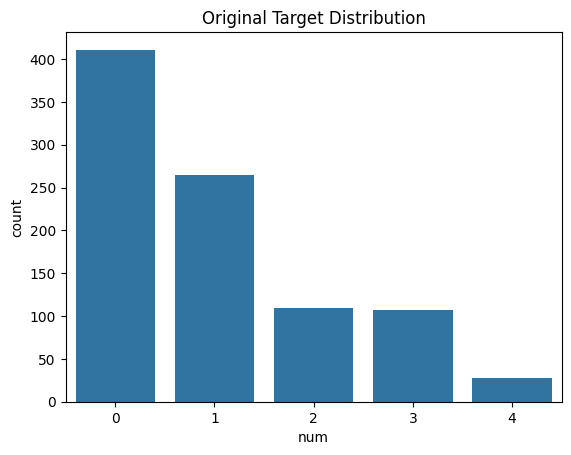


Binarized Target Distribution:
 num
1    509
0    411
Name: count, dtype: int64

Logistic Regression Performance:
Accuracy: 0.7989130434782609
Precision: 0.8529411764705882
Recall: 0.7981651376146789
F1-Score: 0.8246445497630331

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.80      0.76        75
           1       0.85      0.80      0.82       109

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.80      0.80       184

Confusion Matrix:
 [[60 15]
 [22 87]]

Random Forest Performance:
Accuracy: 0.8315217391304348
Precision: 0.89
Recall: 0.8165137614678899
F1-Score: 0.8516746411483254

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.85      0.81        75
           1       0.89      0.82      0.85       109

    accuracy                           0.83       184
   macro

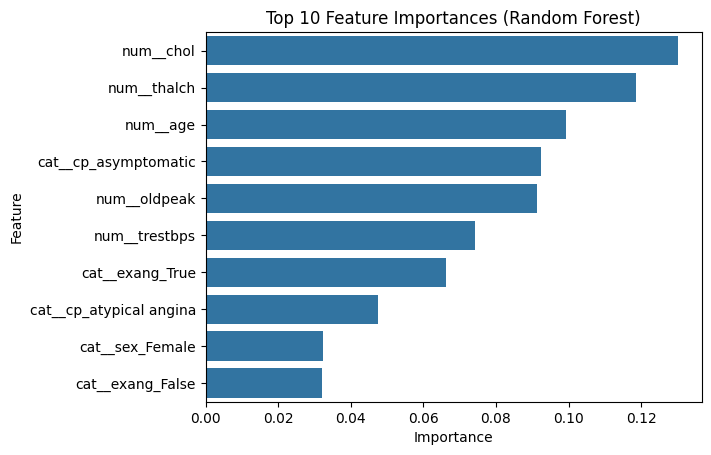

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('heart_disease_uci.csv')

# EDA: Basic info
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['num'].value_counts())

# Visualize target (binarized later)
sns.countplot(x='num', data=df)
plt.title('Original Target Distribution')
plt.show()

# Preprocessing
# Drop irrelevant columns
df = df.drop(['id', 'dataset'], axis=1)

# Binarize target: 0 = no disease, 1 = disease
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
print("\nBinarized Target Distribution:\n", df['num'].value_counts())

# Separate features and target
X = df.drop('num', axis=1)
y = df['num']

# Identify categorical and numerical columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Handle missing values and encoding in a pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Evaluation
print("\nLogistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("Precision:", precision_score(y_test, lr_preds))
print("Recall:", recall_score(y_test, lr_preds))
print("F1-Score:", f1_score(y_test, lr_preds))
print("\nClassification Report:\n", classification_report(y_test, lr_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_preds))

# Model 2: Random Forest (for comparison)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1-Score:", f1_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))

# Feature Importance (from Random Forest)
feature_names = preprocessor.get_feature_names_out()
importances = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_})
importances = importances.sort_values('Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()